<a href="https://colab.research.google.com/github/GuilhermeMBertolo/CIC_IDS2017/blob/main/CIC_IDS_2017_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIC-IDS-2017 | SVM

In [ ]:
# =====================================================
# 1. Ambiente e configuracao experimental
# =====================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

SEED = 314159
np.random.seed(SEED)

PASTA = '/content/drive/MyDrive/CIC-IDS-2017/'
ARQUIVOS = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

NOMES_CLASSES = [
    'BENIGN', 'DoS', 'DDoS', 'Brute Force',
    'Web Attack', 'Reconnaissance', 'Bot', 'Raros',
]


In [ ]:
# =====================================================
# 2. Carga, limpeza e agrupamento das classes
# =====================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Ambiente local detectado. Ajuste PASTA para a pasta dos CSVs.')


def carregar_e_preparar(pasta, arquivos):
    tabelas = []
    for arquivo in arquivos:
        dados = pd.read_csv(os.path.join(pasta, arquivo), low_memory=False)
        dados.columns = dados.columns.str.strip()
        tabelas.append(dados)

    df = pd.concat(tabelas, ignore_index=True)
    df['Label'] = df['Label'].replace({
        'Web Attack Ã¯Â¿Â½ Brute Force': 'Web Attack - Brute Force',
        'Web Attack Ã¯Â¿Â½ Sql Injection': 'Web Attack - Sql Injection',
        'Web Attack Ã¯Â¿Â½ XSS': 'Web Attack - XSS',
        'Web Attack � Brute Force': 'Web Attack - Brute Force',
        'Web Attack � Sql Injection': 'Web Attack - Sql Injection',
        'Web Attack � XSS': 'Web Attack - XSS',
    })

    antes = len(df)
    df = df.dropna()
    colunas_numericas = df.select_dtypes(include=np.number).columns
    df = df.loc[np.isfinite(df[colunas_numericas]).all(axis=1)]
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Linhas removidas na limpeza: {antes - len(df):,}')

    grupos = {
        'BENIGN': 'BENIGN',
        'DoS Hulk': 'DoS', 'DoS GoldenEye': 'DoS',
        'DoS Slowhttptest': 'DoS', 'DoS slowloris': 'DoS',
        'DDoS': 'DDoS',
        'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
        'Web Attack - Brute Force': 'Web Attack',
        'Web Attack - Sql Injection': 'Web Attack',
        'Web Attack - XSS': 'Web Attack',
        'PortScan': 'Reconnaissance', 'Bot': 'Bot',
        'Infiltration': 'Raros', 'Heartbleed': 'Raros',
    }
    codigos = {nome: indice for indice, nome in enumerate(NOMES_CLASSES)}

    df['Label_grupo'] = df['Label'].map(grupos)
    df = df.dropna(subset=['Label_grupo']).copy()
    df['Label_final'] = df['Label_grupo'].map(codigos).astype(int)

    X = df.drop(columns=['Label', 'Label_grupo', 'Label_final'])
    y = df['Label_final']
    print(f'Dataset final: {X.shape[0]:,} linhas e {X.shape[1]} atributos')
    display(df['Label_grupo'].value_counts().reindex(NOMES_CLASSES).to_frame('quantidade'))
    return X, y


Mounted at /content/drive


In [ ]:
# =====================================================
# 3. Divisao estratificada: 80% treino, 10% validacao, 10% teste
# =====================================================

X, y = carregar_e_preparar(PASTA, ARQUIVOS)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED, shuffle=True,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED, shuffle=True,
)

resumo_divisao = pd.DataFrame({
    'Conjunto': ['Treino', 'Validacao', 'Teste'],
    'Linhas': [len(X_train), len(X_val), len(X_test)],
    'Percentual': [len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)],
})
resumo_divisao['Percentual'] = (resumo_divisao['Percentual'] * 100).round(2)
display(resumo_divisao)


Linhas removidas na limpeza: 309,945
Dataset final: 2,520,798 linhas e 78 atributos


,quantidade
Label_grupo,
BENIGN,2095057
DoS,193745
DDoS,128014
Brute Force,9150
Web Attack,2143
Reconnaissance,90694
Bot,1948
Raros,47


,Conjunto,Linhas,Percentual
0,Treino,2016638,80.0
1,Validacao,252080,10.0
2,Teste,252080,10.0


In [ ]:
# =====================================================
# 4. Selecao de atributos por importancia do XGBoost
# =====================================================

# Mesmo criterio de selecao usado no MLP de referencia: 95% da importancia acumulada.
seletor_xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(NOMES_CLASSES),
    eval_metric='mlogloss',
    random_state=SEED,
    tree_method='hist',
    n_estimators=200,
    learning_rate=0.10,
    max_depth=6,
    n_jobs=-1,
)
seletor_xgb.fit(X_train, y_train)

importancias = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': seletor_xgb.feature_importances_,
}).sort_values('Importance', ascending=False)
importancias['Importancia_acumulada'] = importancias['Importance'].cumsum() / importancias['Importance'].sum()

features_selecionadas = importancias.loc[
    importancias['Importancia_acumulada'] <= 0.95,
    'Feature',
].tolist()

if not features_selecionadas:
    features_selecionadas = [importancias.iloc[0]['Feature']]

print(f'Features selecionadas: {len(features_selecionadas)}')
display(importancias.head(20))


Features selecionadas: 21


,Feature,Importance,Importancia_acumulada
13,Bwd Packet Length Std,0.213418,0.213418
74,Idle Mean,0.134505,0.347923
76,Idle Max,0.116660,0.464584
12,Bwd Packet Length Mean,0.061026,0.525610
30,Fwd PSH Flags,0.054695,0.580304
68,act_data_pkt_fwd,0.053228,0.633532
52,Average Packet Size,0.050233,0.683766
4,Total Length of Fwd Packets,0.044570,0.728336
14,Flow Bytes/s,0.031720,0.760056
35,Bwd Header Length,0.031349,0.791405


In [ ]:
# =====================================================
# 5. Normalizacao ajustada somente no treino
# =====================================================

scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train[features_selecionadas])
X_val_z = scaler.transform(X_val[features_selecionadas])
X_test_z = scaler.transform(X_test[features_selecionadas])


In [ ]:
# =====================================================
# 6. Escolha rapida de C no conjunto de validacao
# =====================================================

# A escolha de C usa amostras estratificadas para evitar treinar varios SVMs
# completos. O teste final continua isolado e o modelo final e treinado depois.
MAX_TREINO_BUSCA_C = 80_000
MAX_VALIDACAO_BUSCA_C = 40_000


def amostra_estratificada_array(X_array, y_array, max_linhas, seed):
    y_array = np.asarray(y_array)
    if len(y_array) <= max_linhas:
        return X_array, y_array

    indices = np.arange(len(y_array))
    indices_amostra, _ = train_test_split(
        indices,
        train_size=max_linhas,
        stratify=y_array,
        random_state=seed,
        shuffle=True,
    )
    return X_array[indices_amostra], y_array[indices_amostra]


X_train_c, y_train_c = amostra_estratificada_array(
    X_train_z, y_train.to_numpy(), MAX_TREINO_BUSCA_C, SEED,
)
X_val_c, y_val_c = amostra_estratificada_array(
    X_val_z, y_val.to_numpy(), MAX_VALIDACAO_BUSCA_C, SEED + 1,
)

print(f'Amostra para busca de C: {len(X_train_c):,} treino e {len(X_val_c):,} validacao')

valores_c = [0.1, 1.0, 10.0]
resultados_validacao = []

for c in valores_c:
    modelo = LinearSVC(
        C=c,
        class_weight='balanced',
        dual=False,
        tol=1e-3,
        max_iter=2_000,
        random_state=SEED,
    )
    modelo.fit(X_train_c, y_train_c)
    pred_val = modelo.predict(X_val_c)
    resultados_validacao.append({
        'C': c,
        'Accuracy': accuracy_score(y_val_c, pred_val),
        'F1_weighted': f1_score(y_val_c, pred_val, average='weighted', zero_division=0),
        'F1_macro': f1_score(y_val_c, pred_val, average='macro', zero_division=0),
    })

tabela_validacao = pd.DataFrame(resultados_validacao).sort_values('Accuracy', ascending=False)
display(tabela_validacao.style.format({'Accuracy': '{:.4f}', 'F1_weighted': '{:.4f}', 'F1_macro': '{:.4f}'}))

melhor_c = tabela_validacao.iloc[0]['C']
print(f'Melhor C pela acuracia de validacao: {melhor_c}')


Amostra para busca de C: 80,000 treino e 40,000 validacao


,C,Accuracy,F1_weighted,F1_macro
2,10.000000,0.8786,0.9077,0.4927
1,1.000000,0.8676,0.8951,0.4653
0,0.100000,0.8574,0.8833,0.4388


Melhor C pela acuracia de validacao: 10.0


In [ ]:
# =====================================================
# 7. Treino final balanceado e avaliacao no teste isolado
# =====================================================

# Meio termo entre qualidade e tempo:
# - mantem LinearSVC, que costuma dar resultados melhores que o SGD muito rapido;
# - treina em uma amostra estratificada grande de treino + validacao;
# - avalia no teste completo e isolado, preservando a comparacao experimental.
MAX_TREINO_FINAL_SVM = 350_000

X_modelo = np.vstack([X_train_z, X_val_z])
y_modelo = np.concatenate([y_train.to_numpy(), y_val.to_numpy()])

X_modelo_svm, y_modelo_svm = amostra_estratificada_array(
    X_modelo,
    y_modelo,
    MAX_TREINO_FINAL_SVM,
    SEED + 2,
)

print(f'Amostra usada no treino final do SVM: {len(X_modelo_svm):,} de {len(X_modelo):,} linhas')

svm_final = LinearSVC(
    C=melhor_c,
    class_weight='balanced',
    dual=False,
    tol=1e-4,
    max_iter=5_000,
    random_state=SEED,
)
svm_final.fit(X_modelo_svm, y_modelo_svm)
y_pred = svm_final.predict(X_test_z)

print(f'SVM linear treinado com LinearSVC. C escolhido: {melhor_c}')

metricas = pd.DataFrame({
    'Metrica': ['Accuracy', 'Precision weighted', 'Recall weighted', 'F1 weighted', 'F1 macro', 'Balanced accuracy'],
    'Valor': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='macro', zero_division=0),
        balanced_accuracy_score(y_test, y_pred),
    ],
})
metricas['Valor (%)'] = (metricas['Valor'] * 100).round(2)
display(metricas[['Metrica', 'Valor (%)']])

print(classification_report(
    y_test, y_pred, labels=range(len(NOMES_CLASSES)),
    target_names=NOMES_CLASSES, digits=4, zero_division=0,
))


Amostra usada no treino final do SVM: 350,000 de 2,268,718 linhas
SVM linear treinado com LinearSVC. C escolhido: 10.0


,Metrica,Valor (%)
0,Accuracy,89.76
1,Precision weighted,96.10
2,Recall weighted,89.76
3,F1 weighted,92.05
4,F1 macro,51.82
5,Balanced accuracy,61.53


                precision    recall  f1-score   support

        BENIGN     0.9879    0.8958    0.9396    209506
           DoS     0.9884    0.8249    0.8993     19374
          DDoS     0.9864    0.9975    0.9919     12802
   Brute Force     0.7354    0.9628    0.8339       915
    Web Attack     0.0025    0.0047    0.0033       215
Reconnaissance     0.3137    0.9869    0.4760      9070
           Bot     0.0000    0.0000    0.0000       194
         Raros     0.0006    0.2500    0.0013         4

      accuracy                         0.8976    252080
     macro avg     0.5019    0.6153    0.5182    252080
  weighted avg     0.9610    0.8976    0.9205    252080



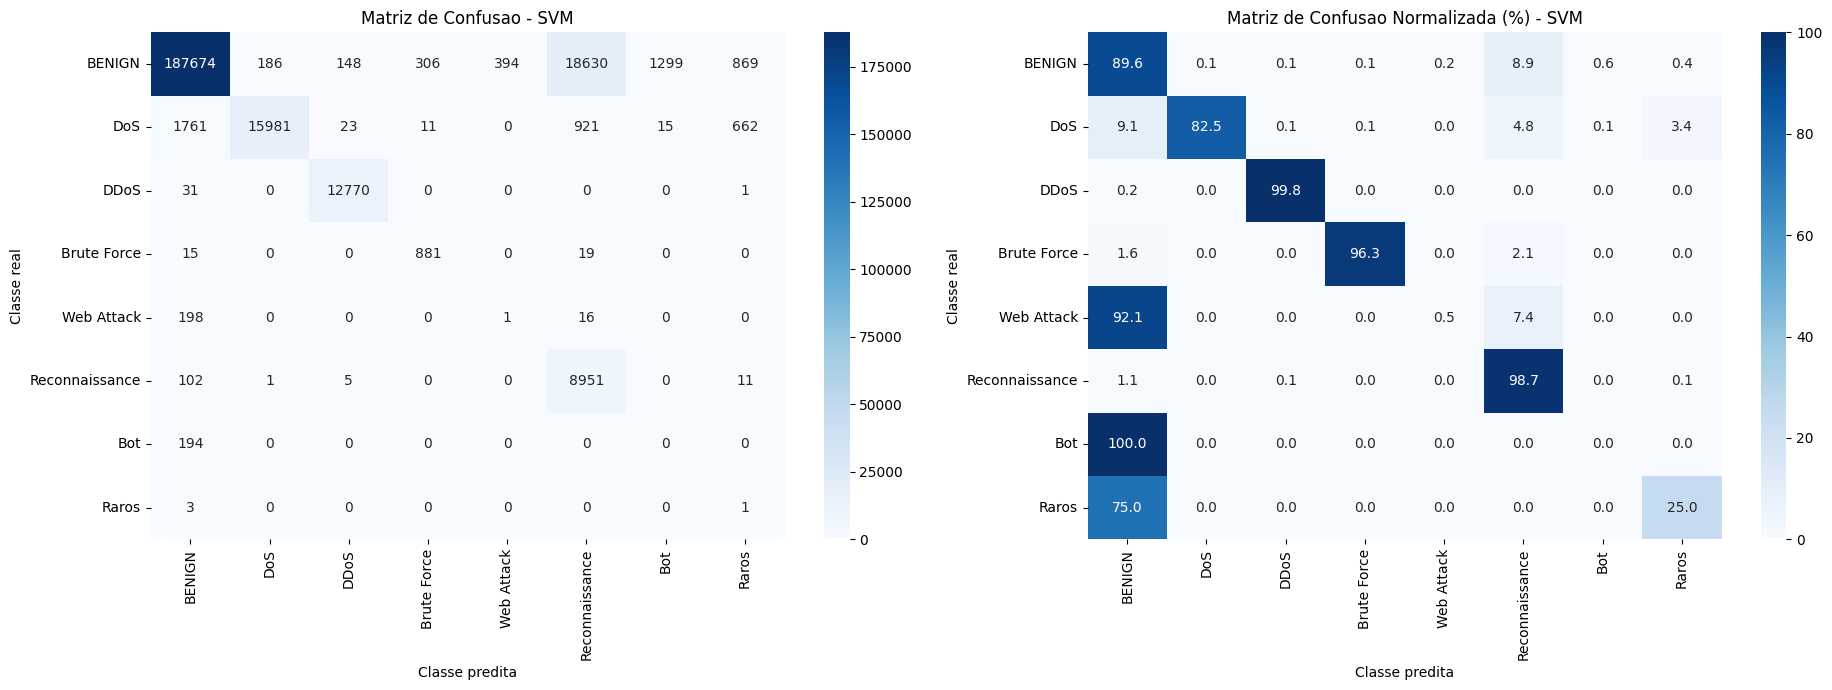

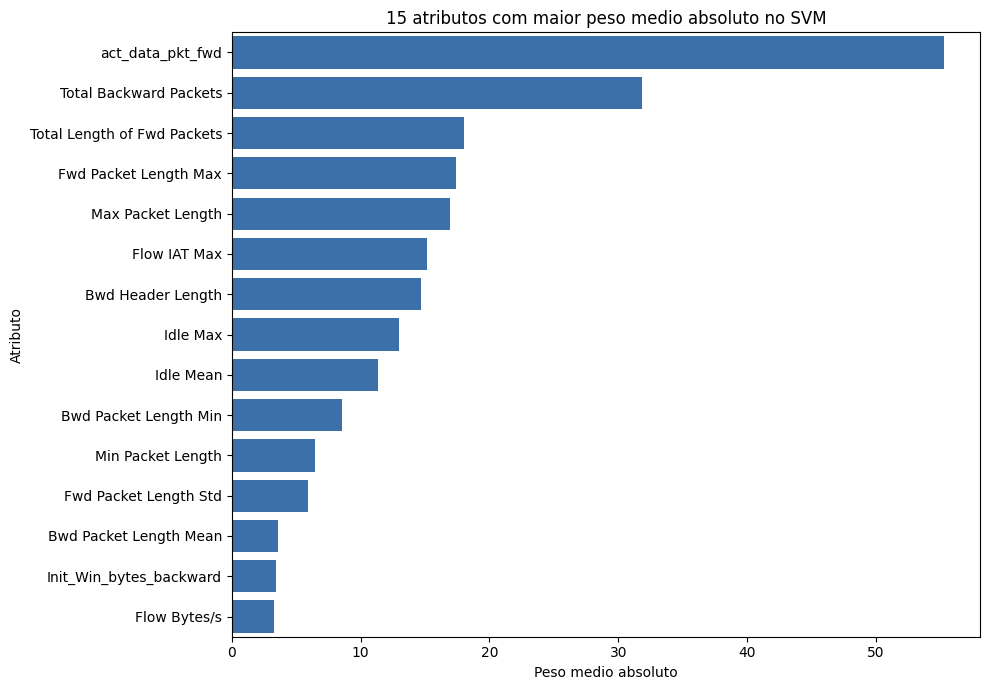

In [ ]:
# =====================================================
# 8. Analise visual e interpretacao do modelo
# =====================================================

cm = confusion_matrix(y_test, y_pred, labels=range(len(NOMES_CLASSES)))
cm_percent = np.nan_to_num(cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(19, 7))
sns.heatmap(pd.DataFrame(cm, index=NOMES_CLASSES, columns=NOMES_CLASSES), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set(title='Matriz de Confusao - SVM', xlabel='Classe predita', ylabel='Classe real')

sns.heatmap(pd.DataFrame(cm_percent, index=NOMES_CLASSES, columns=NOMES_CLASSES), annot=True, fmt='.1f', cmap='Blues', ax=axes[1])
axes[1].set(title='Matriz de Confusao Normalizada (%) - SVM', xlabel='Classe predita', ylabel='Classe real')
plt.tight_layout()
plt.show()

coeficientes = pd.DataFrame({
    'Feature': features_selecionadas,
    'Importancia_media': np.mean(np.abs(svm_final.coef_), axis=0),
}).sort_values('Importancia_media', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=coeficientes.head(15), x='Importancia_media', y='Feature', color='#2a6fbb')
plt.title('15 atributos com maior peso medio absoluto no SVM')
plt.xlabel('Peso medio absoluto')
plt.ylabel('Atributo')
plt.tight_layout()
plt.show()


In [ ]:
# =====================================================
# 9. Quantidade de acertos e desvio padrao
# =====================================================

# Quantidade absoluta de acertos/erros na avaliacao principal da etapa 7.
y_test_array = y_test.to_numpy() if hasattr(y_test, 'to_numpy') else np.asarray(y_test)

quantidade_acertos = int((y_test_array == y_pred).sum())
quantidade_erros = int((y_test_array != y_pred).sum())
total_avaliado = len(y_test_array)

resumo_acertos = pd.DataFrame({
    'Indicador': ['Acertos', 'Erros', 'Total avaliado', 'Taxa de acerto (%)'],
    'Valor': [
        quantidade_acertos,
        quantidade_erros,
        total_avaliado,
        round(quantidade_acertos / total_avaliado * 100, 2),
    ],
})
display(resumo_acertos)

# Estimativa de media e desvio padrao por repeticoes no teste isolado.
# O modelo nao e retreinado; apenas avaliamos amostras estratificadas diferentes
# do teste para manter a execucao controlada.
N_REPETICOES_DESVIO = 5
MAX_TESTE_DESVIO_SVM = 10_000

resultados_repetidos = []

for repeticao in range(N_REPETICOES_DESVIO):
    X_rep, y_rep = amostra_estratificada_array(
        X_test_z,
        y_test_array,
        MAX_TESTE_DESVIO_SVM,
        SEED + 100 + repeticao,
    )
    pred_rep = svm_final.predict(X_rep)
    resultados_repetidos.append({
        'Repeticao': repeticao + 1,
        'Total avaliado': len(y_rep),
        'Acertos': int((y_rep == pred_rep).sum()),
        'Erros': int((y_rep != pred_rep).sum()),
        'Accuracy': accuracy_score(y_rep, pred_rep),
        'Precision weighted': precision_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'Recall weighted': recall_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'F1 weighted': f1_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'F1 macro': f1_score(y_rep, pred_rep, average='macro', zero_division=0),
        'Balanced accuracy': balanced_accuracy_score(y_rep, pred_rep),
    })

resultados_repetidos = pd.DataFrame(resultados_repetidos)
display(resultados_repetidos)

resumo_desvio = resultados_repetidos.drop(columns=['Repeticao']).agg(['mean', 'std']).T
resumo_desvio.columns = ['Media', 'Desvio padrao']

for coluna in ['Media', 'Desvio padrao']:
    resumo_desvio[coluna] = resumo_desvio[coluna].round(4)

display(resumo_desvio)


,Indicador,Valor
0,Acertos,226259.00
1,Erros,25821.00
2,Total avaliado,252080.00
3,Taxa de acerto (%),89.76


,Repeticao,Total avaliado,Acertos,Erros,Accuracy,Precision weighted,Recall weighted,F1 weighted,F1 macro,Balanced accuracy
0,1,10000,8893,1107,0.8893,0.959216,0.8893,0.914549,0.507963,0.662815
1,2,10000,8981,1019,0.8981,0.961859,0.8981,0.921241,0.523871,0.671408
2,3,10000,8987,1013,0.8987,0.961019,0.8987,0.921290,0.517256,0.668656
3,4,10000,8979,1021,0.8979,0.962083,0.8979,0.921265,0.521673,0.675052
4,5,10000,8953,1047,0.8953,0.959103,0.8953,0.918119,0.510506,0.666650


,Media,Desvio padrao
Total avaliado,10000.0000,0.0000
Acertos,8958.6000,38.9204
Erros,1041.4000,38.9204
Accuracy,0.8959,0.0039
Precision weighted,0.9607,0.0014
Recall weighted,0.8959,0.0039
F1 weighted,0.9193,0.0030
F1 macro,0.5163,0.0069
Balanced accuracy,0.6689,0.0046
